In [1]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt

logging.getLogger("matplotlib").setLevel(logging.ERROR)
plt.style.use('default')

sig_level = 5e-8

wgs_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/snippet_analysis/wgs_vs_imputed_array_assoc/results/02.assoc_result/wgs/wgs_vs_array.wgs.sex.10pc.additive.PHENO1.glm.logistic"
array_path = "/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k/snippet_analysis/wgs_vs_imputed_array_assoc/results/02.assoc_result/array/wgs_vs_array.array.sex.10pc.additive.PHENO1.glm.logistic"

In [2]:
wgs_df = pd.read_csv(wgs_path, sep='\t')
array_df = pd.read_csv(array_path, sep='\t')

STEP 1: Initial Data Extraction
WGS original variants:   4,282,768
Array original variants: 4,282,768

STEP 2: Filter Missing or Invalid P-values
WGS variants with invalid P (., NA, inf):        611
Array variants with invalid P (., NA, inf):      645
WGS variants remaining:   4,282,157
Array variants remaining: 4,282,123

STEP 3: Filter Missing or Invalid BETA/SE values
WGS variants with invalid BETA/SE (., NA, inf):          0
Array variants with invalid BETA/SE (., NA, inf):        0
WGS variants remaining:   4,282,157
Array variants remaining: 4,282,123

STEP 4: Merge Common Variants
Common variants after merge: 4,281,886

FILTERING SUMMARY

WGS Variants:
  Original:                  4,282,768
  Removed (invalid P):            611 ( 0.01%)
  Removed (invalid BETA/SE):        0 ( 0.00%)
  Final clean variants:      4,282,157 (99.99%)

Array Variants:
  Original:                  4,282,768
  Removed (invalid P):            645 ( 0.02%)
  Removed (invalid BETA/SE):        0 ( 0.00%)
 

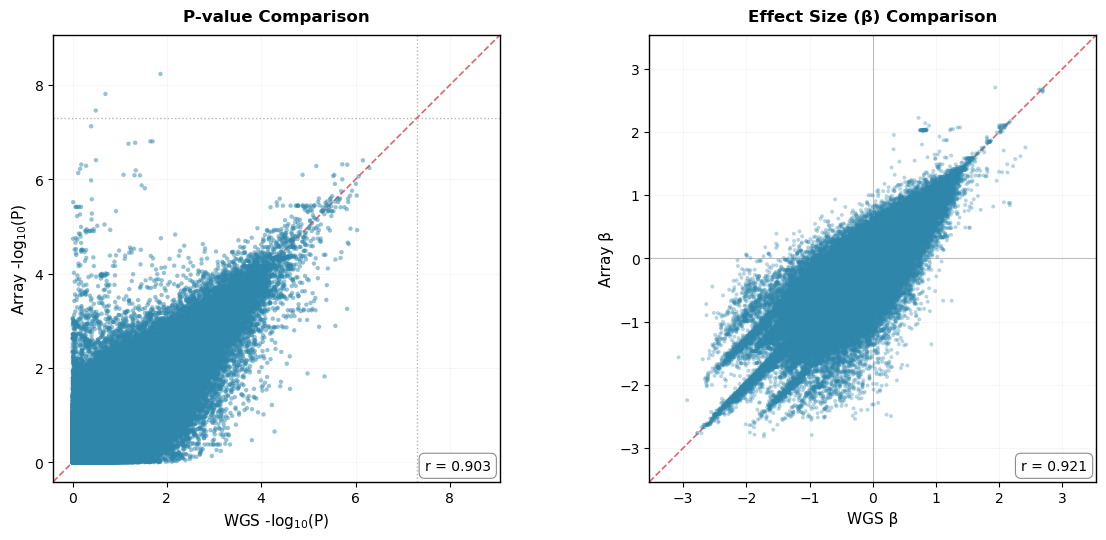


CORRELATION STATISTICS
-log10(P) Pearson correlation: 0.9030
BETA Pearson correlation:      0.9207

TOP 10 SNPS WITH LARGEST P-VALUE DIFFERENCE


: 

In [3]:
# ========== Step 1: Extract initial data ==========
print("=" * 70)
print("STEP 1: Initial Data Extraction")
print("=" * 70)

# Extract P, BETA, SE and SNPID from both datasets
wgs_data = wgs_df[['ID', 'P', 'BETA', 'SE']].copy()
array_data = array_df[['ID', 'P', 'BETA', 'SE']].copy()

# Rename columns for clarity
wgs_data.columns = ['SNPID', 'P_wgs', 'BETA_wgs', 'SE_wgs']
array_data.columns = ['SNPID', 'P_array', 'BETA_array', 'SE_array']

# Count original variants
wgs_original = len(wgs_data)
array_original = len(array_data)

print(f"WGS original variants:   {wgs_original:>8,}")
print(f"Array original variants: {array_original:>8,}")

# ========== Step 2: Remove missing P-values ==========
print("\n" + "=" * 70)
print("STEP 2: Filter Missing or Invalid P-values")
print("=" * 70)

# Mark rows with '.' or NaN in P column
wgs_data['P_wgs'] = wgs_data['P_wgs'].replace('.', np.nan)
array_data['P_array'] = array_data['P_array'].replace('.', np.nan)

# Convert P to numeric
wgs_data['P_wgs'] = pd.to_numeric(wgs_data['P_wgs'], errors='coerce')
array_data['P_array'] = pd.to_numeric(array_data['P_array'], errors='coerce')

# Count variants with invalid P (NaN or inf)
wgs_p_invalid = wgs_data['P_wgs'].isna() | np.isinf(wgs_data['P_wgs'])
array_p_invalid = array_data['P_array'].isna() | np.isinf(array_data['P_array'])

wgs_p_removed = wgs_p_invalid.sum()
array_p_removed = array_p_invalid.sum()

print(f"WGS variants with invalid P (., NA, inf):   {wgs_p_removed:>8,}")
print(f"Array variants with invalid P (., NA, inf): {array_p_removed:>8,}")

# Remove these variants
wgs_data = wgs_data[~wgs_p_invalid].copy()
array_data = array_data[~array_p_invalid].copy()

wgs_after_p = len(wgs_data)
array_after_p = len(array_data)

print(f"WGS variants remaining:   {wgs_after_p:>8,}")
print(f"Array variants remaining: {array_after_p:>8,}")

# ========== Step 3: Remove missing BETA/SE values ==========
print("\n" + "=" * 70)
print("STEP 3: Filter Missing or Invalid BETA/SE values")
print("=" * 70)

# Replace '.' with NaN and convert to numeric
for col in ['BETA_wgs', 'SE_wgs']:
    wgs_data[col] = wgs_data[col].replace('.', np.nan)
    wgs_data[col] = pd.to_numeric(wgs_data[col], errors='coerce')

for col in ['BETA_array', 'SE_array']:
    array_data[col] = array_data[col].replace('.', np.nan)
    array_data[col] = pd.to_numeric(array_data[col], errors='coerce')

# Count variants with invalid BETA or SE (NaN or inf)
wgs_beta_se_invalid = (
    wgs_data['BETA_wgs'].isna() | np.isinf(wgs_data['BETA_wgs']) |
    wgs_data['SE_wgs'].isna() | np.isinf(wgs_data['SE_wgs'])
)

array_beta_se_invalid = (
    array_data['BETA_array'].isna() | np.isinf(array_data['BETA_array']) |
    array_data['SE_array'].isna() | np.isinf(array_data['SE_array'])
)

wgs_beta_se_removed = wgs_beta_se_invalid.sum()
array_beta_se_removed = array_beta_se_invalid.sum()

print(f"WGS variants with invalid BETA/SE (., NA, inf):   {wgs_beta_se_removed:>8,}")
print(f"Array variants with invalid BETA/SE (., NA, inf): {array_beta_se_removed:>8,}")

# Remove these variants
wgs_data = wgs_data[~wgs_beta_se_invalid].copy()
array_data = array_data[~array_beta_se_invalid].copy()

wgs_final = len(wgs_data)
array_final = len(array_data)

print(f"WGS variants remaining:   {wgs_final:>8,}")
print(f"Array variants remaining: {array_final:>8,}")

# ========== Step 4: Merge and finalize ==========
print("\n" + "=" * 70)
print("STEP 4: Merge Common Variants")
print("=" * 70)

# Merge on common SNPIDs
merged_data = pd.merge(wgs_data, array_data, on='SNPID', how='inner')

# Calculate -log10(P) for both datasets
merged_data['neglog10P_wgs'] = -np.log10(merged_data['P_wgs'])
merged_data['neglog10P_array'] = -np.log10(merged_data['P_array'])

# Check for any remaining infinite values after -log10 transformation
inf_check = (
    np.isinf(merged_data['neglog10P_wgs']) | 
    np.isinf(merged_data['neglog10P_array'])
)
inf_removed = inf_check.sum()

if inf_removed > 0:
    print(f"Variants with inf after -log10(P) transformation: {inf_removed:>8,}")
    merged_data = merged_data[~inf_check].copy()

common_variants = len(merged_data)

print(f"Common variants after merge: {common_variants:>8,}")

# ========== Summary Statistics ==========
print("\n" + "=" * 70)
print("FILTERING SUMMARY")
print("=" * 70)

print("\nWGS Variants:")
print(f"  Original:                  {wgs_original:>8,}")
print(f"  Removed (invalid P):       {wgs_p_removed:>8,} ({wgs_p_removed/wgs_original*100:>5.2f}%)")
print(f"  Removed (invalid BETA/SE): {wgs_beta_se_removed:>8,} ({wgs_beta_se_removed/wgs_after_p*100:>5.2f}%)")
print(f"  Final clean variants:      {wgs_final:>8,} ({wgs_final/wgs_original*100:>5.2f}%)")

print("\nArray Variants:")
print(f"  Original:                  {array_original:>8,}")
print(f"  Removed (invalid P):       {array_p_removed:>8,} ({array_p_removed/array_original*100:>5.2f}%)")
print(f"  Removed (invalid BETA/SE): {array_beta_se_removed:>8,} ({array_beta_se_removed/array_after_p*100:>5.2f}%)")
print(f"  Final clean variants:      {array_final:>8,} ({array_final/array_original*100:>5.2f}%)")

print("\nCommon Variants:")
print(f"  Overlapping variants:      {common_variants:>8,}")
print(f"  WGS coverage:              {common_variants/wgs_final*100:>5.2f}% of clean WGS variants")
print(f"  Array coverage:            {common_variants/array_final*100:>5.2f}% of clean Array variants")

print("\n" + "=" * 70)
print("DATA RANGES")
print("=" * 70)
print(f"P-value range (WGS):   {merged_data['P_wgs'].min():.2e} - {merged_data['P_wgs'].max():.2e}")
print(f"P-value range (Array): {merged_data['P_array'].min():.2e} - {merged_data['P_array'].max():.2e}")
print(f"BETA range (WGS):      {merged_data['BETA_wgs'].min():>7.4f} - {merged_data['BETA_wgs'].max():>7.4f}")
print(f"BETA range (Array):    {merged_data['BETA_array'].min():>7.4f} - {merged_data['BETA_array'].max():>7.4f}")

# ========== Visualization ==========
print("\n" + "=" * 70)
print("GENERATING PLOTS")
print("=" * 70)

# Set publication-quality figure parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# ========== Left panel: -log10(P) comparison ==========
# Determine data range for P-value plot
max_val_p = max(merged_data['neglog10P_wgs'].max(), merged_data['neglog10P_array'].max())
min_val_p = 0

# Add padding to axis limits (10% buffer)
padding_p = max_val_p * 0.1
limit_p = max_val_p + padding_p

# Plot scatter with better color
ax1.scatter(merged_data['neglog10P_wgs'], merged_data['neglog10P_array'], 
           alpha=0.5, s=10, c='#2E86AB', edgecolors='none', rasterized=True, zorder=3)

# Set axis limits with padding
ax1.set_xlim(min_val_p - padding_p * 0.5, limit_p)
ax1.set_ylim(min_val_p - padding_p * 0.5, limit_p)

# Add diagonal reference line covering the entire visible range
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax1.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add significance threshold lines
sig_threshold = -np.log10(sig_level)
ax1.axhline(y=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)
ax1.axvline(x=sig_threshold, color='gray', linestyle=':', alpha=0.6, linewidth=1, zorder=1)

# Labels and formatting
ax1.set_xlabel('WGS -log$_{10}$(P)', fontsize=11)
ax1.set_ylabel('Array -log$_{10}$(P)', fontsize=11)
ax1.set_title('P-value Comparison', fontsize=12, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_p = np.corrcoef(merged_data['neglog10P_wgs'], merged_data['neglog10P_array'])[0, 1]
ax1.text(0.98, 0.02, f'r = {corr_p:.3f}', 
        transform=ax1.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# ========== Right panel: BETA comparison ==========
# Determine data range
max_val_beta = max(abs(merged_data['BETA_wgs']).max(), abs(merged_data['BETA_array']).max())

# Add padding to axis limits (15% buffer)
padding_beta = max_val_beta * 0.15
limit_beta = max_val_beta + padding_beta
min_val_beta = -(max_val_beta + padding_beta)

# Plot scatter without error bars for cleaner appearance
ax2.scatter(merged_data['BETA_wgs'], merged_data['BETA_array'],
           alpha=0.35, s=8, c='#2E86AB', edgecolors='none', rasterized=True, zorder=3)

# Set axis limits with padding
ax2.set_xlim(min_val_beta, limit_beta)
ax2.set_ylim(min_val_beta, limit_beta)

# Add diagonal reference line covering the entire visible range
xlim = ax2.get_xlim()
ylim = ax2.get_ylim()
diag_min = max(xlim[0], ylim[0])
diag_max = min(xlim[1], ylim[1])
ax2.plot([diag_min, diag_max], [diag_min, diag_max], 
        color='#E63946', linestyle='--', lw=1.2, alpha=0.8, zorder=2)

# Add zero lines
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.25, linewidth=0.8, zorder=1)

# Labels and formatting
ax2.set_xlabel('WGS β', fontsize=11)
ax2.set_ylabel('Array β', fontsize=11)
ax2.set_title('Effect Size (β) Comparison', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.15, linestyle='-', linewidth=0.5, zorder=0)
ax2.tick_params(axis='both', which='major', labelsize=10)

# Calculate correlation
corr_beta = np.corrcoef(merged_data['BETA_wgs'], merged_data['BETA_array'])[0, 1]
ax2.text(0.98, 0.02, f'r = {corr_beta:.3f}', 
        transform=ax2.transAxes, fontsize=10, 
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                  edgecolor='gray', linewidth=0.8, alpha=0.9))

# Set equal aspect ratio
ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
# plt.savefig('wgs_array_comparison.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('wgs_array_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Reset matplotlib parameters
plt.rcParams.update(plt.rcParamsDefault)

# ========== Correlation Statistics ==========
print("\n" + "=" * 70)
print("CORRELATION STATISTICS")
print("=" * 70)
print(f"-log10(P) Pearson correlation: {corr_p:.4f}")
print(f"BETA Pearson correlation:      {corr_beta:.4f}")

# ========== Top Discordant SNPs ==========
print("\n" + "=" * 70)
print("TOP 10 SNPS WITH LARGEST P-VALUE DIFFERENCE")
print("=" * 70)

merged_data['neglogP_diff'] = np.abs(merged_data['neglog10P_wgs'] - merged_data['neglog10P_array'])
merged_data['BETA_diff'] = np.abs(merged_data['BETA_wgs'] - merged_data['BETA_array'])

top_discordant = merged_data.nlargest(10, 'neglogP_diff')[['SNPID', 'P_wgs', 'P_array', 'BETA_wgs', 'BETA_array', 'neglogP_diff', 'BETA_diff']]
print(top_discordant.to_string(index=False))